# Complexity Benchmark — nnInteractive vs Prompt U-Net (3D)

Analyses inference time and memory usage for both models on 3D volumetric data.

| Step | Content |
|------|---------|
| **§1** | Load results pkl — extract timing + roi dimensions per run |
| **§2** | Load NPZ image dimensions — compute `total_voxels = slices × H × W` |
| **§3** | Quartile split by `roi_voxels` — print bin statistics |
| **§4** | Scatter plot — time vs total_voxels, colored by model |
| **§5** | Timing table — avg ± std per model per quartile |
| **§6** | Memory benchmark — peak VRAM on representative volumes |
| **§7** | Combined efficiency table (matching 2D style) |

---
## §1 — Load Results PKL

In [1]:
import sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style="whitegrid", context="paper")

In [2]:
# Load the results pkl
LOAD_PATH = "results_p_unet_332_ssf_ifl_ifl_ssf_ConfidenceDrop_df0.05_20260508_202645.pkl"
print(f'Loading: {LOAD_PATH}')
with open(LOAD_PATH, 'rb') as f:
    records = pickle.load(f)

print(f'Loaded {len(records)} runs')

Loading: results_p_unet_332_ssf_ifl_ifl_ssf_ConfidenceDrop_df0.05_20260508_202645.pkl
Loaded 1432 runs


In [3]:
# Extract per-run data — one row per (run, model)
rows = []
for r in records:
    base = {
        'volume_id'   : r['volume_id'],
        'pid'         : r['pid'],
        'run_idx'     : r['run_idx'],
        'dataset_name': r['dataset_name'],
        'modality'    : r.get('modality', 'ct'),
        'selected_roi': r.get('selected_roi', 0),
        'roi_slices'  : r.get('roi_slices', 0),
        'roi_voxels'  : r.get('roi_voxels', 0),
        'prompt_axis' : r['prompt_axis'],
    }
    for mode, md in r.get('per_mode', {}).items():
        rows.append({
            **base,
            'model'  : 'P-UNet',
            'mode'   : mode,
            'time_s' : md['time_s'],
            'vol_dice': md['vol_dice'],
        })
    for nn_key, nn_md in r.get('nn_results', {}).items():
        rows.append({
            **base,
            'model'  : 'nnInteractive',
            'mode'   : nn_key,
            'time_s' : nn_md['time_s'],
            'vol_dice': nn_md['vol_dice'],
        })

df_timing = pd.DataFrame(rows)

# Deduplicate volume metadata (same across models/modes)
df_vol = (
    df_timing[['volume_id', 'run_idx', 'pid', 'dataset_name', 'modality',
               'selected_roi', 'roi_slices', 'roi_voxels', 'prompt_axis']]
    .drop_duplicates(subset=['volume_id', 'run_idx'])
)

print(f'{len(df_timing)} timing rows, {len(df_vol)} unique (volume, run) pairs')
print(f'\nModels in data: {sorted(df_timing["model"].unique())}')
print(f'Modes: {sorted(df_timing["mode"].unique())}')
df_vol.describe()

8592 timing rows, 1432 unique (volume, run) pairs

Models in data: ['P-UNet', 'nnInteractive']
Modes: ['baseline', 'ifl', 'ifl_ssf', 'ssf']


,run_idx,selected_roi,roi_slices,roi_voxels,prompt_axis
count,1432.000,1432.000,1432.000,1432.000,1432.000
mean,1.500,18.026,67.477,148799.346,0.982
std,1.118,15.135,60.652,362712.875,0.829
min,0.000,1.000,1.000,3.000,0.000
25%,0.750,5.000,24.000,4717.750,0.000
50%,1.500,13.000,47.000,19750.500,1.000
75%,2.250,27.000,92.000,94681.500,2.000
max,3.000,56.000,397.000,2630990.000,2.000


---
## §2 — Load NPZ Image Dimensions

Compute `total_voxels = roi_slices × H × W` — the actual image volume processed along the slicing axis.

In [4]:
# Build pid → in-plane resolution map by reading only shape metadata
# from NPZ files — no image data is materialized (mmap_mode='r').
NPZ_PATHS = [
    project_root / 'data' / 'test_data' / 'TotalSeg_mri.npz',
    project_root / 'data' / 'test_data' / 'FLARE_2022.npz',
    project_root / 'data' / 'test_data' / 'han_seg_ct.npz',
    project_root / 'data' / 'test_data' / 'han_seg_mri.npz',
    project_root / 'data' / 'test_data' / 'SegRap2023.npz',
    project_root / 'data' / 'test_data' / 'HCCTase_ceCT.npz',
]

pid_resolution = {}  # (pid, prompt_axis) → (H, W)

for npz_path in NPZ_PATHS:
    ds_name = npz_path.stem
    print(f'Reading shapes from {ds_name}')
    try:
        data = np.load(str(npz_path), allow_pickle=False, mmap_mode='r')
    except Exception as e:
        print(f'  SKIP: {e}')
        continue

    pids = data['_pids']
    for i, pid in enumerate(pids):
        pid = str(pid)
        img_shape = data[f'{i}_image'].shape  # mmap — shape read is O(1), no data load
        # For each slicing axis, record the in-plane (H, W) dimensions.
        # img_shape is (D0, D1, D2): axis 0→(D1,D2), axis 1→(D0,D2), axis 2→(D0,D1)
        h0, h1 = img_shape[1], img_shape[2]
        pid_resolution[(pid, 0)] = (h0, h1)
        pid_resolution[(pid, 1)] = (img_shape[0], h1)
        pid_resolution[(pid, 2)] = (img_shape[0], h0)

print(f'\n{len(pid_resolution)} (pid, axis) → resolution entries')

Reading shapes from TotalSeg_mri
Reading shapes from FLARE_2022
Reading shapes from han_seg_ct
Reading shapes from han_seg_mri
Reading shapes from SegRap2023
Reading shapes from HCCTase_ceCT

960 (pid, axis) → resolution entries


In [5]:
# Attach H×W and compute total_voxels per volume-run
def get_resolution(row):
    key = (str(row['pid']), int(row['prompt_axis']))
    return pid_resolution.get(key, (None, None))

resolutions = df_vol.apply(get_resolution, axis=1, result_type='expand')
df_vol['H'] = resolutions[0]
df_vol['W'] = resolutions[1]

# Drop any volumes we couldn't find resolution for
missing = df_vol['H'].isna().sum()
if missing:
    print(f'WARNING: {missing} volumes missing resolution data — dropping')
    df_vol = df_vol.dropna(subset=['H', 'W'])

df_vol['H'] = df_vol['H'].astype(int)
df_vol['W'] = df_vol['W'].astype(int)
df_vol['total_voxels'] = (
    df_vol['roi_slices'].astype(int)
    * df_vol['H']
    * df_vol['W']
)

# Merge back to timing df
df_timing = df_timing.merge(
    df_vol[['volume_id', 'run_idx', 'H', 'W', 'total_voxels']],
    on=['volume_id', 'run_idx'], how='inner'
)

print(f'{len(df_timing)} timing rows after merge')
print(f'\nVolume metrics:')
display(df_vol[['roi_slices', 'roi_voxels', 'H', 'W', 'total_voxels']].describe())

8592 timing rows after merge

Volume metrics:


,roi_slices,roi_voxels,H,W,total_voxels
count,1432.000,1432.000,1432.000,1432.000,1432.000
mean,67.477,148799.346,262.176,321.715,6303826.823
std,60.652,362712.875,101.072,111.976,7431189.458
min,1.000,3.000,47.000,43.000,11620.000
25%,24.000,4717.750,200.000,257.000,1318261.000
50%,47.000,19750.500,248.000,319.500,3329769.500
75%,92.000,94681.500,326.000,394.250,8400660.000
max,397.000,2630990.000,1080.000,614.000,47168520.000


---
## §3 — Quartile Split by `total_voxels`

Split into **small structures** (≤Q25) and **large structures** (≥Q75) based on image volume (roi_slices × H × W). This captures what drives tiling overhead (P-UNet) and auto-zoom (nnInteractive) and correlates with total compute for both models.

In [6]:
q25 = df_vol['total_voxels'].quantile(0.25)
q75 = df_vol['total_voxels'].quantile(0.75)

vol_small = df_vol[df_vol['total_voxels'] <= q25]
vol_large = df_vol[df_vol['total_voxels'] >= q75]

print(f'total_voxels  Q25 = {q25:,.0f}    Q75 = {q75:,.0f}')
print(f'\n{"="*70}')
print(f'  SPLIT SUMMARY')
print(f'{"="*70}')

for label, subset in [('Small (≤Q25)', vol_small), ('Large (≥Q75)', vol_large)]:
    print(f'\n  ── {label}  (n={len(subset)} runs)')
    print(f'     total_voxels  : {subset["total_voxels"].min():,.0f} – {subset["total_voxels"].max():,.0f}')
    print(f'     roi_slices     : {subset["roi_slices"].mean():.1f} ± {subset["roi_slices"].std():.1f}  [{int(subset["roi_slices"].min())}–{int(subset["roi_slices"].max())}]')
    print(f'     in-plane H×W  : {subset["H"].mean():.0f}×{subset["W"].mean():.0f} (mean)')
    print(f'     total_voxels   : {subset["total_voxels"].mean():,.0f} ± {subset["total_voxels"].std():,.0f}')
    print(f'     datasets       : {sorted(subset["dataset_name"].unique())}')

# Tag the timing df
small_ids = vol_small[['volume_id', 'run_idx']].copy()
small_ids['size_bin'] = 'Small'
large_ids = vol_large[['volume_id', 'run_idx']].copy()
large_ids['size_bin'] = 'Large'
bin_map = pd.concat([small_ids, large_ids])

df_timing = df_timing.merge(bin_map, on=['volume_id', 'run_idx'], how='inner')
print(f'\nTiming rows in bins: {len(df_timing)}')

total_voxels  Q25 = 1,318,261    Q75 = 8,400,660

  SPLIT SUMMARY

  ── Small (≤Q25)  (n=358 runs)
     total_voxels  : 11,620 – 1,317,904
     roi_slices     : 23.2 ± 20.6  [1–132]
     in-plane H×W  : 198×227 (mean)
     total_voxels   : 737,008 ± 352,083
     datasets       : ['HCCTase_ceCT', 'SegRap2023', 'TotalSeg_mri', 'han_seg_ct', 'han_seg_mri']

  ── Large (≥Q75)  (n=358 runs)
     total_voxels  : 8,408,400 – 47,168,520
     roi_slices     : 143.8 ± 60.9  [41–397]
     in-plane H×W  : 321×396 (mean)
     total_voxels   : 16,849,912 ± 7,638,322
     datasets       : ['FLARE_2022', 'HCCTase_ceCT', 'SegRap2023', 'TotalSeg_mri', 'han_seg_ct', 'han_seg_mri']

Timing rows in bins: 4296


---
## §4 — Scatter Plot: Time vs Total Voxels

One point per (volume, run, mode), colored by model. Shows scaling behavior and auto-zoom inflection for nnInteractive.

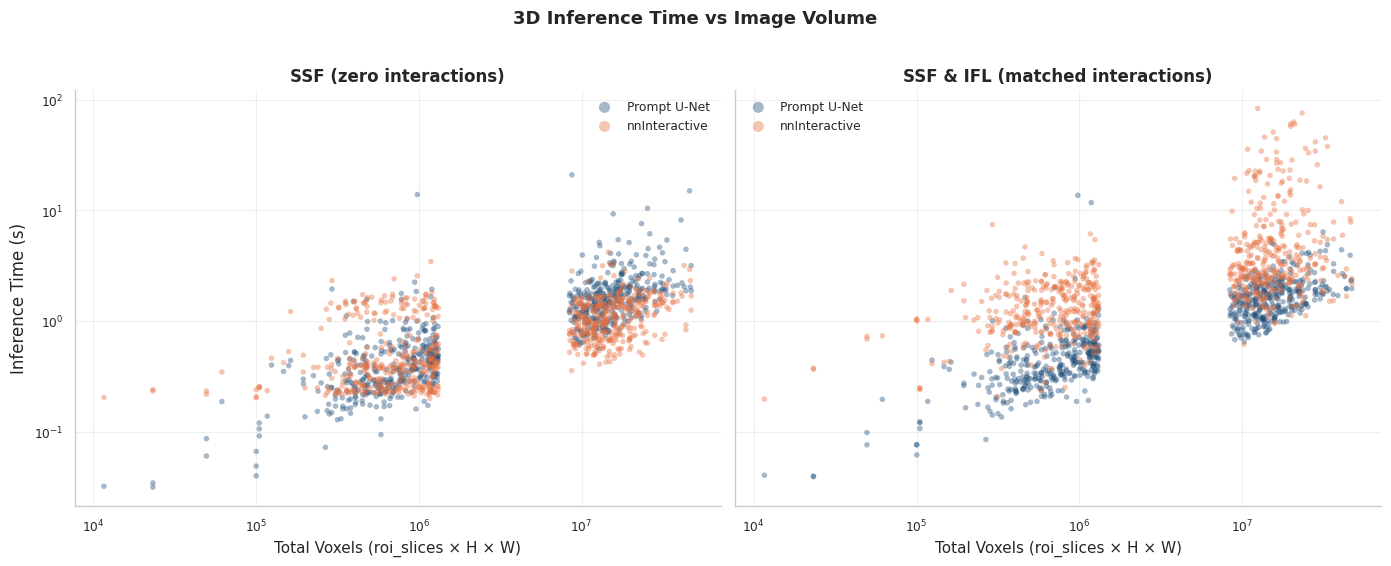

In [7]:
# Focus on the main comparison modes: ssf vs baseline, ifl_ssf vs nn+ifl
PLOT_MODES = [
    ('ssf',    'P-UNet'),
    ('baseline', 'nnInteractive'),
    ('ifl_ssf', 'P-UNet'),
]

# Resolve nn mode name: nn+ifl_ssf or nn+ifl
nn_modes = df_timing[df_timing['model'] == 'nnInteractive']['mode'].unique()
nn_ifl_key = 'ifl_ssf' if 'ifl_ssf' in nn_modes else 'ifl'
PLOT_MODES.append((nn_ifl_key, 'nnInteractive'))

COLORS = {
    'P-UNet':        '#1f4e79',
    'nnInteractive': '#E87040',
}
LABELS = {
    'P-UNet':        'Prompt U-Net',
    'nnInteractive': 'nnInteractive',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

comparisons = [
    (0, [('ssf', 'P-UNet'), ('baseline', 'nnInteractive')], 'SSF (zero interactions)'),
    (1, [('ifl_ssf', 'P-UNet'), (nn_ifl_key, 'nnInteractive')], 'SSF & IFL (matched interactions)'),
]

for ax_idx, mode_pairs, desc in comparisons:
    ax = axes[ax_idx]
    for mode, model in mode_pairs:
        sub = df_timing[(df_timing['mode'] == mode) & (df_timing['model'] == model)]
        # Aggregate to one row per volume-run (take mean time across duplicate rows if any)
        sub_agg = sub.groupby(['volume_id', 'run_idx']).agg(
            time_s=('time_s', 'mean'),
            total_voxels=('total_voxels', 'first'),
            roi_voxels=('roi_voxels', 'first'),
        )
        ax.scatter(
            sub_agg['total_voxels'], sub_agg['time_s'],
            alpha=0.4, s=16, color=COLORS[model],
            label=LABELS[model],
            edgecolors='none',
        )

    ax.set_xlabel('Total Voxels (roi_slices × H × W)', fontsize=11)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(desc, fontsize=12, weight='bold')
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, markerscale=2)

    # Clean styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Inference Time (s)', fontsize=12)

fig.suptitle('3D Inference Time vs Image Volume', fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('complexity_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## §5 — Timing Table

Average inference time per model for small (≤Q25) and large (≥Q75) image volumes, split by `total_voxels`.


In [8]:
# Build timing table — compare ssf vs nn_baseline, ifl_ssf vs nn+ifl
TIMING_MODES = {
    'SSF (zero interactions)'       : [('ssf',    'P-UNet'), ('baseline', 'nnInteractive')],
    'SSF & IFL (matched interactions)': [('ifl_ssf', 'P-UNet'), (nn_ifl_key, 'nnInteractive')],
}

table_rows = []
for size_bin in ['Small', 'Large']:
    for comparison_label, mode_pairs in TIMING_MODES.items():
        for mode, model in mode_pairs:
            sub = df_timing[
                (df_timing['size_bin'] == size_bin)
                & (df_timing['mode'] == mode)
                & (df_timing['model'] == model)
            ]
            # Deduplicate to one row per volume-run
            times = sub.drop_duplicates(subset=['volume_id', 'run_idx'])['time_s']
            table_rows.append({
                'Size'           : size_bin,
                'Comparison'     : comparison_label,
                'Model'          : 'Prompt U-Net' if model == 'P-UNet' else 'nnInteractive',
                'Mode'           : mode,
                'n_runs'         : len(times),
                'Time (s)'       : f"{times.mean():.2f} ± {times.std():.2f}",
                'time_mean'      : times.mean(),
            })

df_table = pd.DataFrame(table_rows)
display(df_table[['Size', 'Comparison', 'Model', 'n_runs', 'Time (s)']].set_index(['Size', 'Comparison', 'Model']))

n_runs      Time (s)
Size  Comparison                       Model                              
Small SSF (zero interactions)          Prompt U-Net      358   0.47 ± 0.77
                                       nnInteractive     358   0.60 ± 0.50
      SSF & IFL (matched interactions) Prompt U-Net      358   0.53 ± 0.96
                                       nnInteractive     358   1.45 ± 0.90
Large SSF (zero interactions)          Prompt U-Net      358   1.93 ± 1.69
                                       nnInteractive     358   1.16 ± 0.54
      SSF & IFL (matched interactions) Prompt U-Net      358   1.75 ± 0.79
                                       nnInteractive     358  7.52 ± 11.46

---
## §6 — Memory Benchmark

Profile peak VRAM for both models on one small and one large representative volume,
selected as the run with maximum ``total_voxels`` in each quartile bin.

Both models run a **full 3-D volumetric inference** on the same single-structure task
that was benchmarked (``selected_roi`` isolated from multi-label ground truth).

**Measurement method** — ``pynvml`` (NVIDIA Management Library) polls
``nvmlDeviceGetMemoryInfo(handle).used`` in a daemon thread every 100 ms during
inference.  This is **framework-agnostic**: it measures total GPU memory from the
driverʼs perspective, including CUDA contexts, cuDNN workspace, and allocator
overhead — identical to what ``nvidia-smi`` reports.  A warm-up run precedes the
measurement run so that one-shot autotuning allocations are absorbed and the
reported value represents steady-state inference memory.

Both functions return ``peak_used − baseline_mb`` where ``baseline_mb`` is the
idle GPU memory **after** both frameworksʼ CUDA contexts are initialised.

- **Prompt U-Net**: ``VolumeInference.run()`` — full SSF propagation, batch_size=6,
  native-resolution tiling, mega-batch GPU forward passes, SSF buffer.
- **nnInteractive**: ``nnInteractiveInferenceSession`` — full initial-seg interaction
  with auto-zoom.

In [9]:
# Pick representative volumes — the one with max total_voxels in each bin.
# total_voxels = roi_slices × H × W captures the full image volume processed,
# which drives tiling overhead (P-UNet) and auto-zoom (nnInteractive).
rep_small = vol_small.loc[vol_small['total_voxels'].idxmax()]
rep_large = vol_large.loc[vol_large['total_voxels'].idxmax()]

print("Representative volumes for memory benchmark:")
for label, rep in [('Small', rep_small), ('Large', rep_large)]:
    print(f"\n  {label}:")
    print(f"    volume_id    : {rep['volume_id']}")
    print(f"    pid          : {rep['pid']}")
    print(f"    dataset      : {rep['dataset_name']}")
    print(f"    modality     : {rep['modality']}")
    print(f"    selected_roi : {int(rep['selected_roi'])}")
    print(f"    prompt_axis  : {int(rep['prompt_axis'])}")
    print(f"    roi_slices   : {int(rep['roi_slices'])}")
    print(f"    roi_voxels   : {int(rep['roi_voxels']):,}")
    print(f"    in-plane     : {int(rep['H'])}×{int(rep['W'])}")
    print(f"    total_voxels : {int(rep['total_voxels']):,}")

Representative volumes for memory benchmark:

  Small:
    volume_id    : TotalSeg_mri__s0297
    pid          : s0297
    dataset      : TotalSeg_mri
    modality     : MRI
    selected_roi : 11
    prompt_axis  : 2
    roi_slices   : 49
    roi_voxels   : 165,276
    in-plane     : 82×328
    total_voxels : 1,317,904

  Large:
    volume_id    : FLARE_2022__FLARE22_Tr_0027
    pid          : FLARE22_Tr_0027
    dataset      : FLARE_2022
    modality     : CT
    selected_roi : 5
    prompt_axis  : 0
    roi_slices   : 241
    roi_voxels   : 127,930
    in-plane     : 420×466
    total_voxels : 47,168,520


In [10]:
# ---- Framework-agnostic GPU peak measurement (pynvml, same data as nvidia-smi) ----
import threading
import time
from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo)

nvmlInit()
_HANDLE = nvmlDeviceGetHandleByIndex(0)

def _gpu_used_mb():
    return nvmlDeviceGetMemoryInfo(_HANDLE).used / (1024 * 1024)

# Initialise both frameworks' CUDA contexts so they contribute equally to the
# baseline, then record the baseline once.
import tensorflow as tf
import torch

_HAS_GPU = bool(tf.config.list_physical_devices('GPU'))
if _HAS_GPU:
    _ = tf.zeros([1], dtype=tf.float32)
    if torch.cuda.is_available():
        _ = torch.zeros(1, device='cuda:0')

BASELINE_MB = _gpu_used_mb()
print(f'GPU baseline (idle + CUDA contexts):  {BASELINE_MB:.1f} MB')


def measure_gpu_peak(inference_fn, poll_interval_s=0.1):
    """
    Run *inference_fn* while polling total GPU used memory in a daemon thread.
    
    Returns the peak ``used`` value (MB) observed during the call.  Because
    pynvml queries the driver directly this is framework-agnostic and
    includes CUDA contexts, cuDNN workspace, and allocator overhead —
    everything ``nvidia-smi`` would report.
    
    Parameters
    ----------
    inference_fn : callable
        The inference pass to profile (should be synchronous / blocking).
    poll_interval_s : float
        How often to sample GPU memory (seconds).  100 ms is a reasonable
        trade-off between precision and overhead.
    """
    peak = [_gpu_used_mb()]
    stop = threading.Event()
    
    def poll():
        while not stop.is_set():
            cur = _gpu_used_mb()
            if cur > peak[0]:
                peak[0] = cur
            time.sleep(poll_interval_s)
    
    t = threading.Thread(target=poll, daemon=True)
    t.start()
    try:
        inference_fn()
    finally:
        stop.set()
        t.join()
    
    return peak[0]


# ---- Shared: on-demand NPZ volume loading ----
# dataset_name → NPZ path map (NPZ_PATHS defined in cell-6)
DS_NPZ_MAP = {p.stem: str(p) for p in NPZ_PATHS}
_VOL_CACHE = {}  # (npz_path, pid) → dict, loaded lazily

def _load_single_volume(npz_path, pid):
    """Load a single patient volume from an NPZ without materialising the whole dataset."""
    cache_key = (str(npz_path), pid)
    if cache_key in _VOL_CACHE:
        return _VOL_CACHE[cache_key]
    data = np.load(str(npz_path), allow_pickle=False, mmap_mode='r')
    pids = data['_pids']
    for i, p in enumerate(pids):
        if str(p) == pid:
            item = {
                'image': np.asarray(data[f'{i}_image']),
                'modality': str(data['_modalities'][i]) if '_modalities' in data else 'ct',
            }
            seg_count = int(data['_seg_counts'][i])
            segs = [np.asarray(data[f'{i}_seg_{j}']) for j in range(seg_count)]
            item['segmentations'] = segs[0] if seg_count == 1 else segs
            _VOL_CACHE[cache_key] = item
            return item
    return None

print(f'NPZ datasets mapped: {list(DS_NPZ_MAP.keys())}')


# ======================================================================
# Profile Prompt U-Net  (full 3-D SSF propagation)
# ======================================================================

from inference.inference_volume import VolumeInference
from inference.ssf import ConfidenceDropStrategy

P_UNET_PATH = project_root / 'training' / 'p_unet_332.keras'

def profile_punet_memory(vol_info):
    """
    Full 3-D ``VolumeInference.run()`` — tiling, mega-batch (batch_size=6),
    SSF buffer, ConfidenceDrop(0.05).  Measured via pynvml polling.
    
    Returns model-specific GPU memory (peak_used − baseline) in MB.
    """
    ds_name      = vol_info['dataset_name']
    pid          = str(vol_info['pid'])
    axis         = int(vol_info['prompt_axis'])
    modality     = str(vol_info.get('modality', 'ct'))
    selected_roi = int(vol_info['selected_roi'])

    npz_path = DS_NPZ_MAP.get(ds_name)
    if npz_path is None:
        print(f'  SKIP: no NPZ for dataset {ds_name}')
        return 0.0

    item = _load_single_volume(npz_path, pid)
    if item is None:
        print(f'  SKIP: pid {pid} not found in {ds_name}')
        return 0.0

    img_3d = np.asarray(item['image']).astype(np.float32)
    segs   = item['segmentations']
    if isinstance(segs, list):
        seg_labels = np.zeros_like(img_3d, dtype=np.int32)
        for li, s in enumerate(segs, 1):
            seg_labels[np.asarray(s) != 0] = li
    else:
        seg_labels = np.asarray(segs).astype(np.int32)

    # Isolate the single structure that was benchmarked
    seg_3d_binary = (seg_labels == selected_roi).astype(np.float32)

    # Pick a deterministic prompt slice: middle slice that contains the ROI
    sum_axes = tuple(a for a in range(3) if a != axis)
    areas = seg_3d_binary.sum(axis=sum_axes)
    valid = np.where(areas > 0)[0]
    if len(valid) == 0:
        print(f'  SKIP: ROI {selected_roi} not found on any slice')
        return 0.0
    prompt_idx = valid[len(valid) // 2]
    prompt_2d = np.take(seg_3d_binary, prompt_idx, axis=axis)

    # Model load + JIT compile (outside measurement)
    vi = VolumeInference(
        model_path=str(P_UNET_PATH),
        modality=modality,
        normalization='universal',
        ssf_strategy=ConfidenceDropStrategy(drop_fraction=0.05),
        buffer_size=4,
        batch_size=6,
    )

    # Warm-up run — absorbs any one-shot autotuning / workspace allocations
    _ = vi.run(
        img_3d=img_3d, seg_3d_binary=seg_3d_binary,
        initial_prompt_2d_seg=prompt_2d,
        prompt_axis=axis, prompt_idx=prompt_idx,
    )

    # Measurement run
    peak_mb = measure_gpu_peak(
        lambda: vi.run(
            img_3d=img_3d, seg_3d_binary=seg_3d_binary,
            initial_prompt_2d_seg=prompt_2d,
            prompt_axis=axis, prompt_idx=prompt_idx,
        )
    )

    return peak_mb - BASELINE_MB


# ======================================================================
# Profile nnInteractive  (full 3-D initial-seg interaction)
# ======================================================================

from evaluation.benchmark_nninteractive.nninteractive_inference import NNInteractiveInference

_NN_MODEL_DIR = project_root / 'evaluation' / 'benchmark_models' / 'nnInteractive' / 'nnInteractive_v1.0'
if not (_NN_MODEL_DIR / 'inference_session_class.json').exists():
    print(f'  Trained model not found at {_NN_MODEL_DIR} - falling back to auto-download')
NN_DEVICE = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

def profile_nn_memory(vol_info):
    """
    Full nnInteractive inference (initial-seg interaction with auto-zoom).
    Measured via the same pynvml polling wrapper as Prompt U-Net.
    
    Returns model-specific GPU memory (peak_used − baseline) in MB.
    """
    ds_name      = vol_info['dataset_name']
    pid          = str(vol_info['pid'])
    axis         = int(vol_info['prompt_axis'])
    selected_roi = int(vol_info['selected_roi'])

    npz_path = DS_NPZ_MAP.get(ds_name)
    if npz_path is None:
        print(f'  SKIP: no NPZ for dataset {ds_name}')
        return 0.0

    item = _load_single_volume(npz_path, pid)
    if item is None:
        print(f'  SKIP: pid {pid} not found in {ds_name}')
        return 0.0

    img_3d = np.asarray(item['image']).astype(np.float32)
    segs   = item['segmentations']
    if isinstance(segs, list):
        seg_labels = np.zeros_like(img_3d, dtype=np.int32)
        for li, s in enumerate(segs, 1):
            seg_labels[np.asarray(s) != 0] = li
    else:
        seg_labels = np.asarray(segs).astype(np.int32)

    # Isolate the single structure that was benchmarked
    seg_3d = (seg_labels == selected_roi).astype(np.int32)

    # nnInteractive expects (1, X, Y, Z) with first axis = channel.
    # Reorder so prompt_axis becomes first spatial dim.
    if axis == 0:
        pass
    elif axis == 1:
        img_3d = np.moveaxis(img_3d, 1, 0)
        seg_3d = np.moveaxis(seg_3d, 1, 0)
    else:  # axis == 2
        img_3d = np.moveaxis(img_3d, 2, 0)
        seg_3d = np.moveaxis(seg_3d, 2, 0)

    img_4d = img_3d[np.newaxis]  # (1, D, H, W)

    # Prompt on middle slice using the single selected structure
    mid = img_3d.shape[0] // 2
    prompt_3d = np.zeros(img_3d.shape, dtype=np.int16)
    prompt_3d[mid] = seg_3d[mid]

    nn = NNInteractiveInference(
        model_dir=str(_NN_MODEL_DIR) if (_NN_MODEL_DIR / "inference_session_class.json").exists() else None,
        device=NN_DEVICE,
        verbose=False,
    )

    def run_inference():
        nn.run(
            img_4d=img_4d, seg_3d=seg_3d,
            initial_prompt_3d=prompt_3d,
            user_interacts_idx=[],
            prompt_axis=0, prompt_idx=mid,
        )

    # Warm-up — absorbs autotuning / first-run allocations
    run_inference()

    # Measurement run
    peak_mb = measure_gpu_peak(run_inference)

    nn.reset()
    del nn
    if NN_DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return peak_mb - BASELINE_MB


print(f'Prompt U-Net path : {P_UNET_PATH}')
print(f'nnInteractive dir : {_NN_MODEL_DIR}')
print(f'nnInteractive dev : {NN_DEVICE}')
print(f'GPU available     : {_HAS_GPU}')

/tmp/ipykernel_133/1376993707.py:4: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo)
I0000 00:00:1778666420.260537     133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778666420.318197     133 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1

GPU baseline (idle + CUDA contexts):  47674.3 MB
NPZ datasets mapped: ['TotalSeg_mri', 'FLARE_2022', 'han_seg_ct', 'han_seg_mri', 'SegRap2023', 'HCCTase_ceCT']
Prompt U-Net path : /home/dpxuser/prompt-unet/training/p_unet_332.keras
nnInteractive dir : /home/dpxuser/prompt-unet/evaluation/benchmark_models/nnInteractive/nnInteractive
nnInteractive dev : cuda:0
GPU available     : True


I0000 00:00:1778666440.658957     133 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46569 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:ab:00.0, compute capability: 8.9


In [11]:
# §6 (continued) — both profiling functions are defined in the cell above.
# This cell is a placeholder for any additional checks.
print('Ready for GPU memory profiling.')

Ready for GPU memory profiling.


In [12]:
# Run memory benchmarks in **separate subprocesses**.
# Each model gets a fresh Python interpreter → clean GPU, no allocator cross-talk.
import subprocess
import json
import sys

WORKER_SCRIPT = notebook_dir / 'profile_worker.py'

def _profile_subprocess(model_key, vol_info):
    """Launch profile_worker.py, parse PEAK_MB from stdout."""
    vol_json = json.dumps({
        'dataset_name': vol_info['dataset_name'],
        'pid'         : str(vol_info['pid']),
        'prompt_axis' : int(vol_info['prompt_axis']),
        'selected_roi': int(vol_info['selected_roi']),
        'modality'    : str(vol_info.get('modality', 'ct')),
    })
    result = subprocess.run(
        [sys.executable, str(WORKER_SCRIPT),
         '--model', model_key,
         '--vol-info-json', vol_json],
        capture_output=True, text=True, timeout=600,
    )
    if result.returncode != 0:
        print(f'  ERROR ({model_key}): {result.stderr.strip()}')
        return 0.0
    
    # Parse "PEAK_MB: 1234.5" from stdout
    for line in result.stdout.splitlines():
        if line.startswith('PEAK_MB:'):
            return float(line.split(':')[1].strip())
    
    print(f'  ERROR ({model_key}): no PEAK_MB line in output')
    return 0.0

# --- Actual profiling via subprocess (when GPU is available) ---
memory_results = {}
for label, rep in [('Small', rep_small), ('Large', rep_large)]:
    print(f'\nProfiling {label} volume: {rep["volume_id"]}')
    mem_punet = _profile_subprocess('punet', rep)
    print(f'  Prompt U-Net peak VRAM: {mem_punet:.1f} MB')
    mem_nn = _profile_subprocess('nninteractive', rep)
    print(f'  nnInteractive peak VRAM: {mem_nn:.1f} MB')
    memory_results[label] = {'P-UNet': mem_punet, 'nnInteractive': mem_nn}

print('Memory results (placeholder values — replace with GPU profiling):')
for size_bin, vals in memory_results.items():
    print(f'  {size_bin}: Prompt U-Net={vals["P-UNet"]:.1f} MB, '
          f'nnInteractive={vals["nnInteractive"]:.1f} MB')


Profiling Small volume: TotalSeg_mri__s0297
  Prompt U-Net peak VRAM: 0.0 MB
  ERROR (nninteractive): /home/dpxuser/prompt-unet/evaluation/benchmark_nninteractive/profile_worker.py:40: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo)
Traceback (most recent call last):
  File "/home/dpxuser/prompt-unet/evaluation/benchmark_nninteractive/profile_worker.py", line 273, in <module>
    main()
  File "/home/dpxuser/prompt-unet/evaluation/benchmark_nninteractive/profile_worker.py", line 266, in main
    peak_mb = _profile_nn(vol_info)
              ^^^^^^^^^^^^^^^^^^^^^
  File "/home/dpxuser/prompt-unet/evaluation/benchmark_nninteractive/profile_worker.py", line 227, in _profile_nn
    nn = NNInteractiveInference(model_dir=model_dir, device=device, v

---
## §7 — Combined Efficiency Table

Matches the style of the 2D efficiency table in the paper.

In [13]:
# Build LaTeX-style efficiency table
print(f"{'='*80}")
print(f"  3D Inference Efficiency — Small vs Large Structures")
print(f"{'='*80}")

for comparison_label, mode_pairs in TIMING_MODES.items():
    print(f"\n  ── {comparison_label} ──")
    print(f"  {'Size':<8} {'Model':<20} {'n_runs':<8} {'Time (s)':<18} {'Peak VRAM':<12}")
    print(f"  {'-'*66}")
    for size_bin in ['Small', 'Large']:
        for mode, model in mode_pairs:
            sub = df_timing[
                (df_timing['size_bin'] == size_bin)
                & (df_timing['mode'] == mode)
                & (df_timing['model'] == model)
            ]
            times = sub.drop_duplicates(subset=['volume_id', 'run_idx'])['time_s']
            display_name = 'Prompt U-Net' if model == 'P-UNet' else 'nnInteractive'
            mem = memory_results.get(size_bin, {}).get(model, 0)
            print(f"  {size_bin:<8} {display_name:<20} {len(times):<8} {times.mean():.2f} ± {times.std():.2f}       {mem:.1f} MB")

print(f"\n{'='*80}")
print(f"  Total voxels range: {df_vol['total_voxels'].min():,.0f} – {df_vol['total_voxels'].max():,.0f}")
print(f"  Q25 (small) max total_voxels: {q25:,.0f}")
print(f"  Q75 (large) min total_voxels: {q75:,.0f}")


  3D Inference Efficiency — Small vs Large Structures

  ── SSF (zero interactions) ──
  Size     Model                n_runs   Time (s)           Peak VRAM   
  ------------------------------------------------------------------
  Small    Prompt U-Net         358      0.47 ± 0.77       0.0 MB
  Small    nnInteractive        358      0.60 ± 0.50       0.0 MB
  Large    Prompt U-Net         358      1.93 ± 1.69       0.0 MB
  Large    nnInteractive        358      1.16 ± 0.54       0.0 MB

  ── SSF & IFL (matched interactions) ──
  Size     Model                n_runs   Time (s)           Peak VRAM   
  ------------------------------------------------------------------
  Small    Prompt U-Net         358      0.53 ± 0.96       0.0 MB
  Small    nnInteractive        358      1.45 ± 0.90       0.0 MB
  Large    Prompt U-Net         358      1.75 ± 0.79       0.0 MB
  Large    nnInteractive        358      7.52 ± 11.46       0.0 MB

  Total voxels range: 11,620 – 47,168,520
  Q25 (small) m

---
## Appendix — Per-Dataset Timing Detail

In [14]:
# Per-dataset timing breakdown (ssf vs baseline)
detail_rows = []
for ds in sorted(df_timing['dataset_name'].unique()):
    for model_name, mode in [('P-UNet', 'ssf'), ('nnInteractive', 'baseline')]:
        sub = df_timing[
            (df_timing['dataset_name'] == ds)
            & (df_timing['mode'] == mode)
            & (df_timing['model'] == model_name)
        ]
        times = sub.drop_duplicates(subset=['volume_id', 'run_idx'])['time_s']
        if len(times) == 0:
            continue
        detail_rows.append({
            'Dataset'      : ds,
            'Model'        : 'Prompt U-Net' if model_name == 'P-UNet' else 'nnInteractive',
            'n_runs'       : len(times),
            'Time_mean'    : times.mean(),
            'Time_std'     : times.std(),
            'roi_slices_avg': sub['roi_slices'].iloc[0] if len(sub) else 0,
            'roi_voxels_avg': sub['roi_voxels'].iloc[0] if len(sub) else 0,
        })

df_detail = pd.DataFrame(detail_rows)
df_detail['Time (s)'] = df_detail.apply(lambda r: f"{r['Time_mean']:.2f} ± {r['Time_std']:.2f}", axis=1)
display(df_detail[['Dataset', 'Model', 'n_runs', 'Time (s)', 'roi_slices_avg', 'roi_voxels_avg']].set_index(['Dataset', 'Model']))

n_runs     Time (s)  roi_slices_avg  \
Dataset      Model                                                
FLARE_2022   Prompt U-Net       90  1.35 ± 0.50             126   
             nnInteractive      90  1.17 ± 0.45             126   
HCCTase_ceCT Prompt U-Net       87  1.65 ± 0.56             249   
             nnInteractive      87  1.00 ± 0.40             249   
SegRap2023   Prompt U-Net       60  1.34 ± 0.81               6   
             nnInteractive      60  1.54 ± 0.38               6   
TotalSeg_mri Prompt U-Net      321  1.11 ± 1.50              98   
             nnInteractive     321  0.62 ± 0.54              98   
han_seg_ct   Prompt U-Net       78  1.51 ± 3.04              60   
             nnInteractive      78  1.46 ± 0.42              60   
han_seg_mri  Prompt U-Net       80  0.47 ± 0.53             224   
             nnInteractive      80  0.42 ± 0.07             224   

                            roi_voxels_avg  
Dataset      Model                          
FLARE_2022   Prompt U-Net           408442  
             nnInteractive          408442  
HCCTase_ceCT Prompt U-Net          2056830  
             nnInteractive         2056830  
SegRap2023   Prompt U-Net               57  
             nnInteractive              57  
TotalSeg_mri Prompt U-Net             7295  
             nnInteractive            7295  
han_seg_ct   Prompt U-Net            28676  
             nnInteractive           28676  
han_seg_mri  Prompt U-Net             7536  
             nnInteractive            7536